In [1]:
import numpy as np
np.set_printoptions(suppress=True, precision=6)
import pandas as pd
import shap
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('mtData.csv')

X = data.drop('GPU', axis=1)
y = data['GPU']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_log = np.log(y_train)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.fit_transform(X_test)

cols = ['total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

features = ['elements', 'blocks', 'threadsPerBlock',
       'total global memory(KB)', 'clock rate(KHz)', 'multiprocessor count',
       'async engine count', 'memory bus width', 'memory clock rate (KHz)',
       'L2 cache size (bytes)', 'max threads per SM']

device_specs = data[cols].drop_duplicates().to_numpy()

#device_specs[0] = cuda2
#device_specs[1] = cuda3
#device_specs[2] = cuda4
#device_specs[3] = cuda5

In [2]:
model = XGBRegressor(
    n_estimators=10000,
    max_depth = 8,
    learning_rate=0.1,
    random_state=42)

model.fit(X_train, y_log)

preds_log = model.predict(X_test)
preds = np.exp(preds_log)
# preds[:6], y_test.to_numpy()[:6]
# preds[6:12], y_test.to_numpy()[6:12]
preds[12:18], y_test.to_numpy()[12:18]

(array([0.004808, 0.018088, 0.003371, 0.009561, 0.000519, 0.000534],
       dtype=float32),
 array([0.005026, 0.017989, 0.003136, 0.010653, 0.000523, 0.000519]))

In [3]:
blocks = np.array([32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768])
threads = np.array([32, 50, 64, 100, 128, 200, 256, 400, 512, 750, 1024])
num_elements = 10000000

results = []
for b in blocks:
    for t in threads:
            input_features = np.concatenate([np.array([num_elements, b, t], dtype='float64'), device_specs[2]]).reshape(-1, 11)

            res = np.exp(model.predict(input_features))

            results.append([b, t, res[0]])

results = np.array(results)

sorted = results[results[:, 2].argsort()]

min_b, min_tpb, min_time = results[np.argmin(results[:, 2])]
print(f'Best Config:')
print(f'Blocks: {int(min_b)} | Threads Per Block: {int(min_tpb)} | Time: {min_time:.6f}s')

print("\nBest device: cuda4")
print("Device Specs:\n")

for name, spec in zip(cols, device_specs[2]):
    print(f'{name}: {spec}')

Best Config:
Blocks: 32768 | Threads Per Block: 100 | Time: 0.000510s

Best device: cuda4
Device Specs:

total global memory(KB): 12492800
clock rate(KHz): 1215500
multiprocessor count: 24
async engine count: 2
memory bus width: 384
memory clock rate (KHz): 3505000
L2 cache size (bytes): 3145728
max threads per SM: 2048


In [4]:
print('Top 10 Best Configurations:')

for s in range(10):
    nb, tpb, time = sorted[s]
    print(f'Blocks: {int(nb)} | Threads Per Block: {int(tpb)} | Time: {time:.6f}s')

#Compare with test set
sorted_df = data[(data['elements'] == num_elements)].sort_values(by='GPU')
sorted_df.head(10)

Top 10 Best Configurations:
Blocks: 32768 | Threads Per Block: 100 | Time: 0.000510s
Blocks: 32768 | Threads Per Block: 64 | Time: 0.000511s
Blocks: 16384 | Threads Per Block: 400 | Time: 0.000511s
Blocks: 8192 | Threads Per Block: 750 | Time: 0.000514s
Blocks: 32768 | Threads Per Block: 32 | Time: 0.000515s
Blocks: 32768 | Threads Per Block: 750 | Time: 0.000515s
Blocks: 16384 | Threads Per Block: 200 | Time: 0.000516s
Blocks: 16384 | Threads Per Block: 1024 | Time: 0.000518s
Blocks: 16384 | Threads Per Block: 750 | Time: 0.000519s
Blocks: 32768 | Threads Per Block: 1024 | Time: 0.000520s


,elements,blocks,threadsPerBlock,GPU,total global memory(KB),clock rate(KHz),multiprocessor count,async engine count,memory bus width,memory clock rate (KHz),L2 cache size (bytes),max threads per SM
5665,10000000,16384,32,0.000513,12492800,1215500,24,2,384,3505000,3145728,2048
5673,10000000,16384,512,0.000513,12492800,1215500,24,2,384,3505000,3145728,2048
5664,10000000,8192,1024,0.000513,12492800,1215500,24,2,384,3505000,3145728,2048
5684,10000000,32768,512,0.000515,12492800,1215500,24,2,384,3505000,3145728,2048
5667,10000000,16384,64,0.000515,12492800,1215500,24,2,384,3505000,3145728,2048
5686,10000000,32768,1024,0.000516,12492800,1215500,24,2,384,3505000,3145728,2048
5676,10000000,32768,32,0.000516,12492800,1215500,24,2,384,3505000,3145728,2048
5662,10000000,8192,512,0.000516,12492800,1215500,24,2,384,3505000,3145728,2048
5677,10000000,32768,50,0.000517,12492800,1215500,24,2,384,3505000,3145728,2048
5674,10000000,16384,750,0.000517,12492800,1215500,24,2,384,3505000,3145728,2048


In [5]:
#Compare with Ground Truth for 10m Elements
# ground truth gathered by running many configurations of blocks and threadsPerBlock on CIMS servers
# with fixed number of elements for 20 iterations each and taking their mean stratified by configuration
# note: all GT configurations ran on the system with the best overall performance (cuda4 in this case)

gt = pd.read_csv('mtGT10m.csv')
gt = gt.groupby(['blocks', 'threadsPerBlock']).mean().reset_index().sort_values('GPU')
gt.head(10)

,blocks,threadsPerBlock,elements,GPU
89,8192,50,10000000.0,0.000520
96,8192,512,10000000.0,0.000521
94,8192,256,10000000.0,0.000521
73,2048,400,10000000.0,0.000521
114,32768,128,10000000.0,0.000522
92,8192,128,10000000.0,0.000522
105,16384,256,10000000.0,0.000523
76,2048,1024,10000000.0,0.000523
111,32768,50,10000000.0,0.000523
115,32768,200,10000000.0,0.000523


In [20]:
gt.shape, X_test.shape

((121, 4), (1936, 11))

In [ ]:
# Normalize time and predictions as a percentage of the maximum execution time for each "problem_size"
X_test["time"] = y_test
X_test["pred"] = preds
# Group by "problem_size" and compute normalization factor (max)
grouped_max_time = X_test.groupby("image_size")["time"].transform("max")

# Normalize actual time as a percentage of the max
X_test["normalized_time"] = (X_test["time"] / grouped_max_time) * 100

# Group by "problem_size" and compute normalization factor (max) for predictions
grouped_max_preds = X_test.groupby("image_size")["pred"].transform("max")

# Normalize predictions as a percentage of the max
X_test["normalized_pred"] = (X_test["pred"] / grouped_max_preds) * 100

# Extract normalized predictions as a NumPy array (if needed)
normalized_preds = X_test["normalized_pred"].values

# Calculate absolute error
X_test["absolute_error"] = np.abs(X_test["normalized_pred"] - X_test["normalized_time"])

# Group by "problem_size" and calculate MAE
mae_by_g


Top 5 most important features (XGBoost):
                   Feature  Importance
2  total global memory(KB)    0.822897
0                   blocks    0.081840
3          clock rate(KHz)    0.039247
1          threadsPerBlock    0.020438
4     multiprocessor count    0.001416

Top 5 most important features (SHAP):
                   Feature  SHAP_Importance
2  total global memory(KB)         0.667714
0                   blocks         0.317187
3          clock rate(KHz)         0.105856
1          threadsPerBlock         0.102224
4     multiprocessor count         0.004714


<Figure size 1000x500 with 0 Axes>

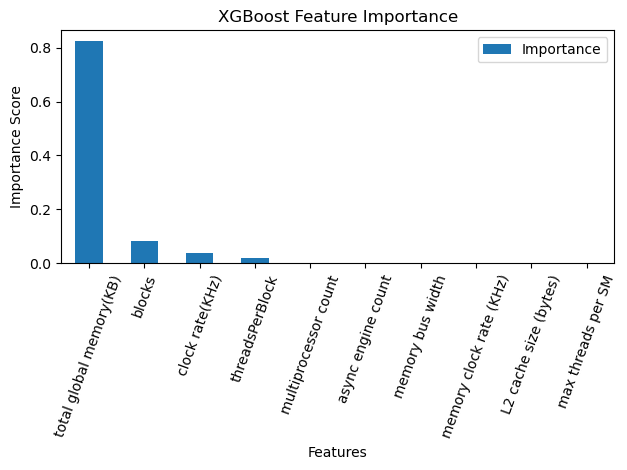

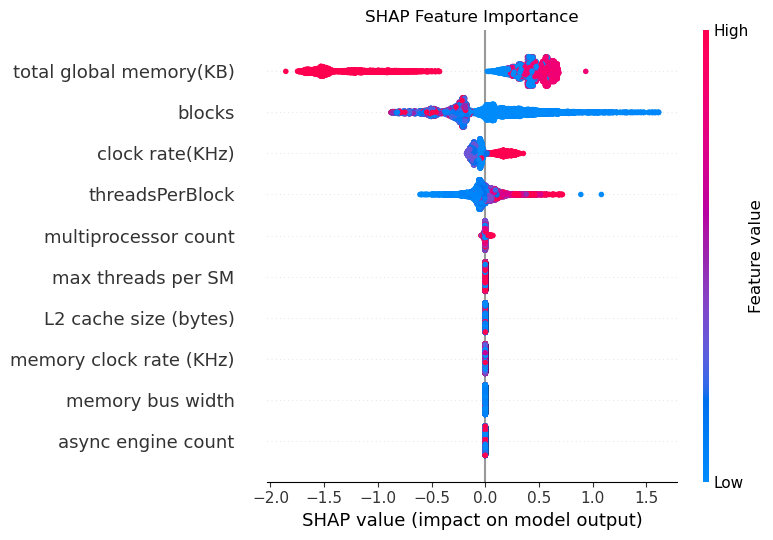

In [13]:
def analyze_feature_importance(model, X_train, exclude, feature_names=None):
    
    if isinstance(exclude, str):
        exclude_idx = feature_names.index(exclude)
    else:
        exclude_idx = exclude
    
    include_names = [name for i, name in enumerate(feature_names) if i != exclude_idx]
    
    importance_values = model.feature_importances_
    importance_dict = {
        name: score for name, score in zip(
            feature_names, 
            importance_values
        ) if name != feature_names[exclude_idx]
    }
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Importance': list(importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    #running shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train)
    
    # exclude 'elements'
    if isinstance(X_train, pd.DataFrame):
        X_train_filtered = X_train.drop(columns=[feature_names[exclude_idx]])
    else:
        X_train_filtered = np.delete(X_train, exclude_idx, axis=1)
    
    shap_values_filtered = np.delete(shap_values, exclude_idx, axis=1)
    
    # mean absolute shap values for each input feature
    # absolute value because we want to measure total impact, positive or negative on the comptue time
    mean_shap = pd.DataFrame({
        'Feature': include_names,
        'SHAP_Importance': np.abs(shap_values_filtered).mean(axis=0)
    }).sort_values('SHAP_Importance', ascending=False)
    

    fig_xgb = plt.figure(figsize=(10, 5))
    importance_df.plot(x='Feature', y='Importance', kind='bar')
    plt.title('XGBoost Feature Importance')
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=70)
    plt.tight_layout()
    
    fig_shap = plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values_filtered, X_train_filtered, 
                     feature_names=include_names, show=False)
    plt.title('SHAP Feature Importance')
    plt.tight_layout()
    
    return {
        'xgboost_importance': importance_df,
        'shap_importance': mean_shap,
        'shap_values': shap_values_filtered,
        'figure_xgb': fig_xgb,
        'figure_shap': fig_shap
    }

results = analyze_feature_importance(model, X_train, exclude='elements', feature_names=features)

print("\nTop 5 most important features (XGBoost):")
print(results['xgboost_importance'].head())

print("\nTop 5 most important features (SHAP):")
print(results['shap_importance'].head())

plt.show()
